In [2]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

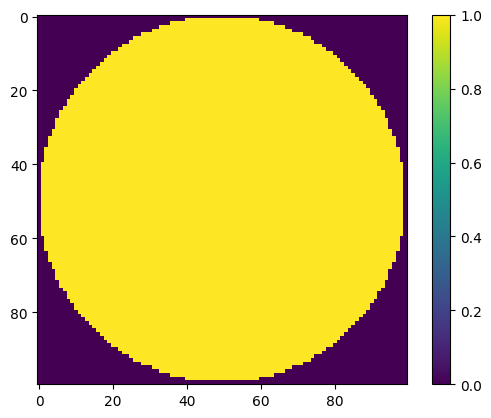

In [ ]:
#creating the aperture space
N = 100
aperture = np.zeros(shape=(N,N),dtype=complex)

x_pos = np.linspace(-250, 250, N) # 500 millimeter aperture
y_pos = np.linspace(-250, 250, N)

x_grid,y_grid = np.meshgrid(x_pos,y_pos)

#Computes distance from origin to each grid point
r = np.sqrt(x_grid**2 + y_grid**2)

#Creates circular aperture
aperture[r < 250] = 1.0

"""for i in range(len(x_pos)):
    for j in range(len(y_pos)):
        r = np.sqrt(x_pos[i]**2 + y_pos[j]**2)
        if r < 250:
            aperture[i,j] = 1.0"""


plt.imshow(np.abs(aperture))

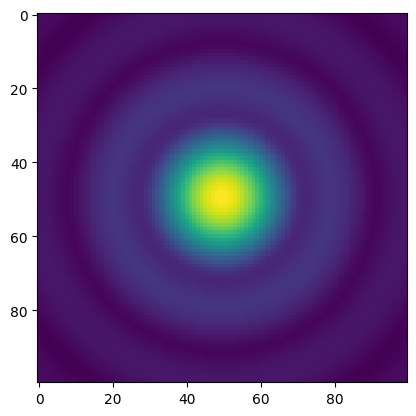

In [4]:
#taking the aperture and seeing where thats projected onto the near field
near_field = np.zeros(shape=(100,100), dtype=complex)
x2 = np.linspace(-1000,1000,100)
y2 = np.linspace(-1000,1000,100)
z = 10000

x_grid2,y_grid2 = np.meshgrid(x2,y2)

for i in range(len(x2)):
    for j in range(len(y2)):
        #finding the distance between the whole aperture and points in a plane
        d = np.sqrt((x_grid - x2[i])**2 + (y_grid - y2[j])**2 + z**2) #2D array of distances 
        near_field[i,j] = np.sum(aperture * np.exp(complex(0,1) * d/3)) #(3) scaling factor for the phase

plt.imshow(np.abs(near_field))


In [5]:
#saved data used to create graphs and data points for aperture and then near field
np.savez("optic_sim_1_5_100.npz", near_field = near_field, aperture = aperture, x_position = x_pos, y_position = y_pos, x_near = x2, y_near =y2)

In [6]:
#showing that data in a plot
#print(x)
#plt.imshow(np.atan2(np.imag(x["near_field"]), np.real(x["near_field"])))

In [7]:
# #plot time vs N (Aperture or N^2)
# #seconds
# run_time = [5.3, 20.9, 207, 842]
# rec_ap = [100,200,500,1000]

# plt.plot(rec_ap, run_time, 'o-', label= 'Simulation runtime')
# plt.xlabel('Aperture size N')
# plt.ylabel('Runtime (seconds)')
# plt.title('Runtime vs Aperture size')
# plt.grid(True)
# plt.legend()
# plt.show()

In [8]:
# #loading the data saved into a variable
# optic_sim_12_12_1000 = np.load("optic_sim_12_12_1000.npz")
# optic_sim_1_5_500   = np.load("optic_sim_1_5_500.npz")
# optic_sim_1_5_200   = np.load("optic_sim_1_5_200.npz")
# optic_sim_1_5_100   = np.load("optic_sim_1_5_100.npz")

In [9]:
# #image comparison 
# #loading the data saved into a variable

# fig, axes = plt.subplots(1, 4, figsize=(20,5))

# axes[0].imshow(np.abs(optic_sim_12_12_1000["near_field"]), interpolation='nearest')
# axes[0].set_title("N = 1000")

# axes[1].imshow(np.abs(optic_sim_1_5_500["near_field"]), interpolation='nearest')
# axes[1].set_title("N = 500")

# axes[2].imshow(np.abs(optic_sim_1_5_200["near_field"]), interpolation='nearest')
# axes[2].set_title("N = 200")

# axes[3].imshow(np.abs(optic_sim_1_5_100["near_field"]), interpolation='nearest')
# axes[3].set_title("N = 100")

# plt.show()